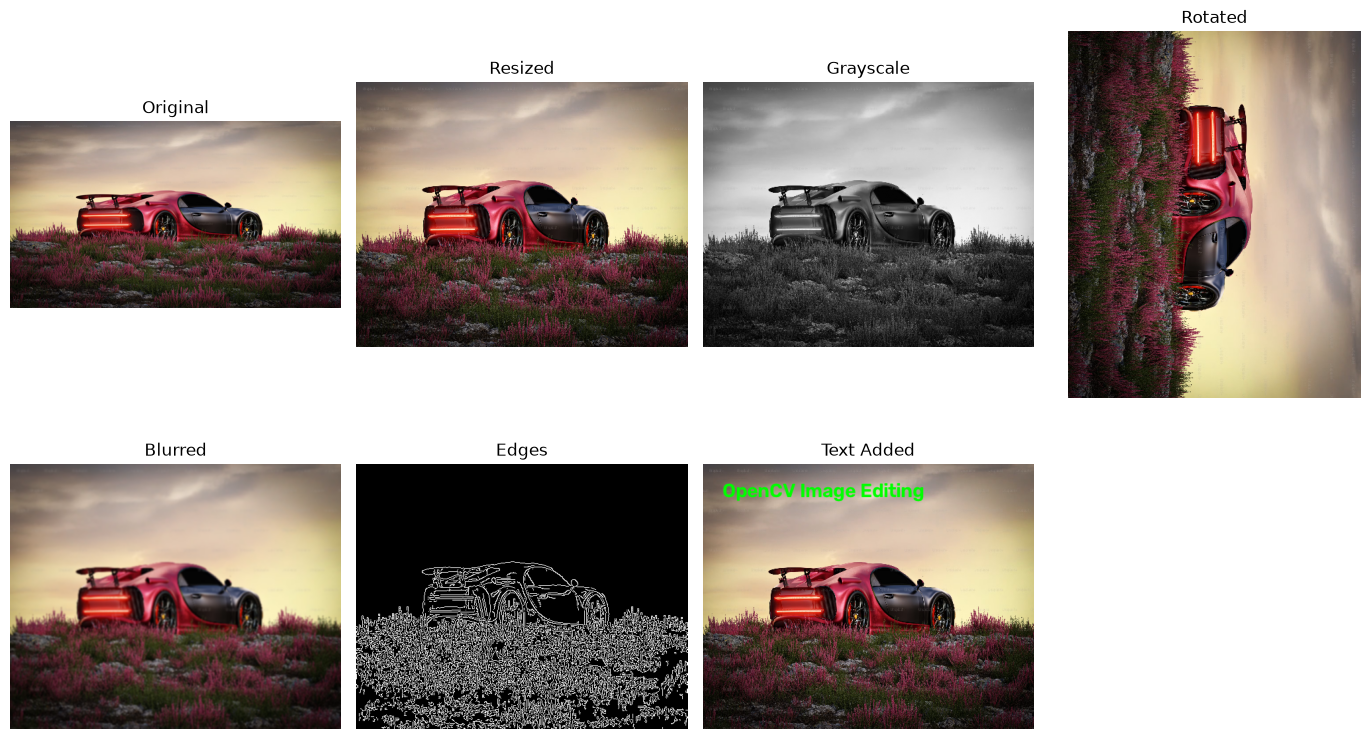

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

# Read the image, supporting both JPG and the attached AVIF file.
image_path = Path("input.jpg")
avif_path = Path("premium_photo-1737182592549-0c83f93e2903.avif")

if image_path.exists():
    img = cv2.imread(str(image_path))
elif avif_path.exists():
    rgb_image = np.array(Image.open(avif_path).convert("RGB"))
    img = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)
else:
    # Create a demo image when no input image is available.
    img = np.zeros((400, 500, 3), dtype=np.uint8)
    cv2.putText(img, "Demo Image", (130, 210),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 120, 255), 3)

# 1. Resize the image
resize = cv2.resize(img, (500, 400))

# 2. Convert image to grayscale
gray = cv2.cvtColor(resize, cv2.COLOR_BGR2GRAY)

# 3. Rotate the image
rotate = cv2.rotate(resize, cv2.ROTATE_90_CLOCKWISE)

# 4. Blur the image
blur = cv2.GaussianBlur(resize, (5, 5), 0)

# 5. Detect edges
edges = cv2.Canny(resize, 100, 200)

# 6. Add text to the image
text = resize.copy()
cv2.putText(text, "OpenCV Image Editing",
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1, (0, 255, 0), 2)

# Display all results inline in the notebook
images = [img, resize, gray, rotate, blur, edges, text]
titles = ["Original", "Resized", "Grayscale", "Rotated", "Blurred", "Edges", "Text Added"]

plt.figure(figsize=(14, 8))
for index, (image, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 4, index)
    if len(image.shape) == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()